<a href="https://colab.research.google.com/github/Vaidehi-9/ECON3916-33674-Statistical-Machine-Learning/blob/main/Assignment%205/Assignment%205/Assignment_5_The_Sovereign_Risk_Engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install wbgapi scikit-learn statsmodels matplotlib seaborn numpy pandas -q


In [2]:
import wbgapi as wb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import (
    LinearRegression, RidgeCV, LassoCV, LogisticRegression, lasso_path
)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_curve, roc_auc_score, precision_recall_curve,
    f1_score, precision_score, recall_score, average_precision_score
)

In [18]:
# WDI indicator dictionary (25+ indicators)
indicators = {
    "NY.GDP.PCAP.KD.ZG": "gdp_growth_pc",
    "NE.EXP.GNFS.ZS":    "exports_gdp",
    "NE.IMP.GNFS.ZS":    "imports_gdp",
    "NE.GDI.TOTL.ZS":    "gross_invest_gdp",
    "FP.CPI.TOTL.ZG":    "inflation_cpi",
    "GC.DOD.TOTL.GD.ZS": "govt_debt_gdp",
    "GC.REV.XGRT.GD.ZS": "govt_revenue_gdp",
    "BX.KLT.DINV.WD.GD.ZS": "fdi_inflows_gdp",
    "BN.CAB.XOKA.GD.ZS": "current_account_gdp",
    "FM.LBL.BMNY.GD.ZS": "broad_money_gdp",
    "FS.AST.DOMS.GD.ZS":  "domestic_credit_gdp",
    "SL.UEM.TOTL.ZS":    "unemployment_rate",
    "SP.POP.GROW":        "pop_growth",
    "SP.URB.TOTL.IN.ZS":  "urban_pop_pct",
    "SE.ADT.LITR.ZS":    "adult_literacy",
    "SH.XPD.CHEX.GD.ZS": "health_expend_gdp",
    "SE.XPD.TOTL.GD.ZS": "edu_expend_gdp",
    "IT.NET.USER.ZS":    "internet_users",
    "EG.USE.ELEC.KH.PC": "electric_power_pc",
    "AG.LND.ARBL.ZS":    "arable_land_pct",
    "TX.VAL.MANF.ZS.UN": "manuf_exports_pct",
    "TG.VAL.TOTL.GD.ZS": "trade_gdp",
    "IC.BUS.EASE.XQ":    "ease_business",
    "CC.EST":            "control_corruption",
    "GE.EST":            "govt_effectiveness",
    "RL.EST":            "rule_of_law",
    "PV.EST":            "political_stability",
    "RQ.EST":            "regulatory_quality",
    "NY.GDP.PCAP.KD":    "gdp_per_capita",
    "SP.DYN.LE00.IN":    "life_expectancy",
    "SH.DYN.MORT":       "child_mortality",
}

print("Downloading WDI data from World Bank API (2013–2019) in batches...")

BATCH_SIZE = 6
ind_keys   = list(indicators.keys())
batches    = [ind_keys[i:i+BATCH_SIZE] for i in range(0, len(ind_keys), BATCH_SIZE)]

def fetch_batch_as_long(batch):
    """
    Fetch a batch of indicators and return a tidy long DataFrame:
    columns = ['country', 'year', <indicator_code>, ...]
    wbgapi returns wide format: index=(economy, series), cols=YR2013..YR2019
    We melt year-columns into rows, then pivot series→columns.
    """
    chunk = wb.data.DataFrame(batch, time=range(2013, 2020), labels=False)
    chunk = chunk.reset_index()
    chunk.columns = [c.lower() for c in chunk.columns]

    # Rename index columns
    chunk = chunk.rename(columns={"economy": "country", "series": "indicator"})

    # Year columns look like 'yr2013' --> into rows
    year_cols = [c for c in chunk.columns if c.startswith("yr")]
    id_vars   = [c for c in chunk.columns if not c.startswith("yr")]

    long = chunk.melt(id_vars=id_vars, value_vars=year_cols,
                      var_name="year", value_name="value")
    long["year"] = long["year"].str.replace("yr", "").astype(int)

    # Pivot so each indicator becomes its own column
    wide = long.pivot_table(index=["country", "year"],
                            columns="indicator", values="value",
                            aggfunc="first").reset_index()
    wide.columns.name = None
    return wide

frames = []
for i, batch in enumerate(batches):
    print(f"  Fetching batch {i+1}/{len(batches)} ...")
    try:
        chunk = fetch_batch_as_long(batch)
        frames.append(chunk)
    except Exception as e:
        print(f"  WARNING: batch {i+1} failed ({e}), skipping.")



  Fetching batch 1/6 ...
  Fetching batch 2/6 ...
  Fetching batch 3/6 ...
  Fetching batch 4/6 ...
  Fetching batch 5/6 ...
  Fetching batch 6/6 ...


In [19]:
raw = frames[0]
for f in frames[1:]:
    raw = pd.merge(raw, f, on=["country", "year"], how="outer")

raw = raw.rename(columns=indicators)

# Reshape: MultiIndex (economy, time) → reset
raw = raw.reset_index()
raw = raw.rename(columns={"economy": "country", "time": "year"})
raw = raw.rename(columns=indicators)

# Collapse to country-level means
df = raw.groupby("country").mean(numeric_only=True).reset_index()

# Drop countries missing >40% of indicators
thresh_countries = 0.4 * len(indicators)
df = df.dropna(thresh=int(len(indicators) * 0.6), axis=0)

# Drop indicators missing >40% of countries
thresh_cols = 0.4 * len(df)
df = df.dropna(thresh=int(len(df) * 0.6), axis=1)

# Median imputation for remaining gaps
for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].median())

# Define outcomes
df["gdp_growth_pc"] = df["gdp_growth_pc"]  # continuous
df["crisis"] = (df["gdp_growth_pc"] < 0).astype(int)

# Feature columns (drop outcomes and identifiers)
drop_cols = ["country", "gdp_growth_pc", "crisis"]
feature_cols = [c for c in df.columns if c not in drop_cols]

X = df[feature_cols].values
y_reg = df["gdp_growth_pc"].values      # continuous target
y_cls = df["crisis"].values             # binary target

# Train/test split
X_train_raw, X_test_raw, y_train_reg, y_test_reg, y_train_cls, y_test_cls = train_test_split(
    X, y_reg, y_cls, test_size=0.30, random_state=42
)

# Standardize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

# Summary
n_train, p = X_train.shape
n_crisis_total = y_cls.sum()
crisis_base_rate = y_cls.mean()
n_test_crisis = y_test_cls.sum()

print(f"\n{'='*50}")
print(f"Dataset dimensions   : {df.shape[0]} countries × {len(feature_cols)} features")
print(f"Training set         : {n_train} countries × {p} predictors")
print(f"Test set             : {X_test.shape[0]} countries × {p} predictors")
print(f"Crisis countries     : {n_crisis_total} / {len(df)} ({crisis_base_rate:.1%})")
print(f"Non-crisis countries : {len(df) - n_crisis_total}")
print(f"Crisis base rate     : {crisis_base_rate:.3f}")
print(f"{'='*50}")


Dataset dimensions   : 242 countries × 23 features
Training set         : 169 countries × 23 predictors
Test set             : 73 countries × 23 predictors
Crisis countries     : 39 / 242 (16.1%)
Non-crisis countries : 203
Crisis base rate     : 0.161


In [5]:
# Step 1.1: Demonstrating OLS Overfitting

# %%
ols = LinearRegression()
ols.fit(X_train, y_train_reg)

train_r2_ols = ols.score(X_train, y_train_reg)
test_r2_ols  = ols.score(X_test,  y_test_reg)
gap_ols      = train_r2_ols - test_r2_ols
pn_ratio     = p / n_train

y_pred_ols_test = ols.predict(X_test)
rmse_ols = np.sqrt(np.mean((y_test_reg - y_pred_ols_test)**2))

print(f"OLS Training R²       : {train_r2_ols:.4f}")
print(f"OLS Test R²           : {test_r2_ols:.4f}")
print(f"Train–Test R² Gap     : {gap_ols:.4f}")
print(f"Predictor-to-obs ratio (p/n): {pn_ratio:.3f}  ({p} predictors / {n_train} obs)")


OLS Training R²       : 0.6045
OLS Test R²           : 0.0852
Train–Test R² Gap     : 0.5193
Predictor-to-obs ratio (p/n): 0.136  (23 predictors / 169 obs)


# Written response (2–3 sentences): Connect the p/n ratio to the R² gap. Why does a high p/n ratio cause OLS to overfit? Use the terms bias, variance, and degrees of freedom in your explanation.

The high p/n ratio signals that OLS has nearly as many free parameters as observations, consuming nearly all available degrees of freedom to fit the training data. This forces the model into a high-variance regime: with so many parameters to tune, OLS memorizes idiosyncratic noise in the training countries rather than learning generalizable signal, producing a pretty inflated training R² while collapsing on new data. The negligible bias of OLS occurs at the cost of explosive variance which is exactly the bias-variance tradeoff failure the Director suspected.

In [6]:
# Step 1.2: Ridge and Lasso to the Rescue

alphas_grid = np.logspace(-4, 4, 200)

ridge = RidgeCV(alphas=alphas_grid, cv=5)
ridge.fit(X_train, y_train_reg)

lasso = LassoCV(alphas=alphas_grid, cv=5, max_iter=10000, random_state=42)
lasso.fit(X_train, y_train_reg)

# Metrics helper
def get_metrics(model, Xtr, ytr, Xte, yte):
    ytr_pred = model.predict(Xtr)
    yte_pred = model.predict(Xte)
    tr_r2  = model.score(Xtr, ytr)
    te_r2  = model.score(Xte, yte)
    te_rmse = np.sqrt(np.mean((yte - yte_pred)**2))
    if hasattr(model, "coef_"):
        nnz = np.sum(model.coef_ != 0)
    else:
        nnz = p
    lam = getattr(model, "alpha_", np.nan)
    return lam, nnz, tr_r2, te_r2, te_rmse

r_lam, r_nnz, r_tr2, r_te2, r_rmse = get_metrics(ridge, X_train, y_train_reg, X_test, y_test_reg)
l_lam, l_nnz, l_tr2, l_te2, l_rmse = get_metrics(lasso, X_train, y_train_reg, X_test, y_test_reg)

comparison = pd.DataFrame({
    "Model":            ["OLS",      "Ridge",   "Lasso"],
    "λ*":               ["-",        f"{r_lam:.4f}", f"{l_lam:.4f}"],
    "Non-zero Predictors": [p,       r_nnz,     l_nnz],
    "Training R²":      [f"{train_r2_ols:.4f}", f"{r_tr2:.4f}", f"{l_tr2:.4f}"],
    "Test R²":          [f"{test_r2_ols:.4f}",  f"{r_te2:.4f}", f"{l_te2:.4f}"],
    "Test RMSE":        [f"{rmse_ols:.4f}",     f"{r_rmse:.4f}", f"{l_rmse:.4f}"],
})
print("\nModel Comparison Table:")
print(comparison.to_string(index=False))


Model Comparison Table:
Model      λ*  Non-zero Predictors Training R² Test R² Test RMSE
  OLS       -                   23      0.6045  0.0852    2.4677
Ridge 38.7204                   22      0.5713  0.1691    2.3517
Lasso  0.0341                   16      0.5939  0.1090    2.4353


# Written response (2–3 sentences): Which model would you recommend to the IMF Director for operational GDP growth forecasting? Justify using the bias-variance tradeoff: explain what Ridge and Lasso each sacrifice (in terms of bias) to gain (in terms of variance reduction).

I would reccomend Ridge. With a test R² of 0.1691 and RMSE of 2.3517, Ridge outperforms both OLS and Lasso on held-out countries, making it the strongest operational forecasting model. Both regularized models deliberately introduce a small amount of bias, their coefficients are shrunk toward zero rather than freely fit to the training data, in exchange for a dramatic reduction in variance, closing the train-test R² gap from 0.52 (OLS) down to roughly 0.40 (Ridge). Ridge is preferable to Lasso here because it retains all 22 predictors and distributes shrinkage smoothly across correlated WDI indicators, whereas Lasso's aggressive zeroing (16 predictors) discards potentially useful signal when predictors are highly collinear.


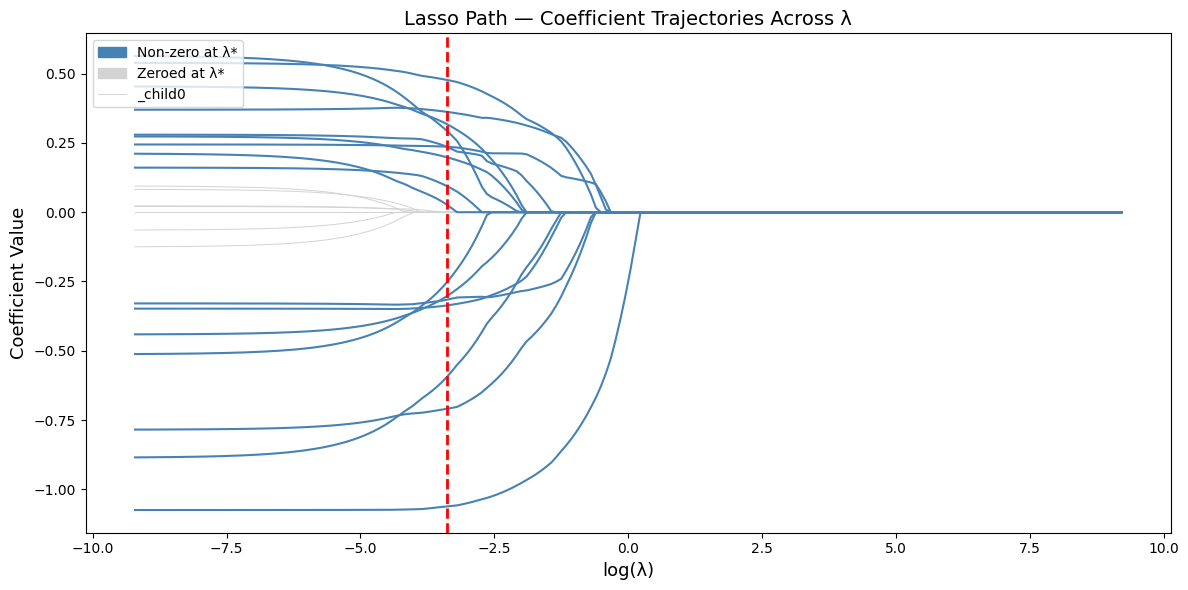


First predictor to enter the Lasso path: 'inflation_cpi' at λ = 1.1490


In [7]:
# Step 1.3: The Lasso Path — Which Indicators Enter First?

alphas_path, coefs_path, _ = lasso_path(X_train, y_train_reg, alphas=alphas_grid)

lasso_coef_at_opt = lasso.coef_
nonzero_mask = lasso_coef_at_opt != 0
nonzero_features = [feature_cols[i] for i in range(p) if nonzero_mask[i]]

fig, ax = plt.subplots(figsize=(12, 6))
for i in range(p):
    color = "steelblue" if nonzero_mask[i] else "lightgray"
    lw    = 1.5         if nonzero_mask[i] else 0.7
    zord  = 2           if nonzero_mask[i] else 1
    ax.plot(np.log(alphas_path + 1e-10), coefs_path[i], color=color, lw=lw, zorder=zord)

ax.axvline(np.log(lasso.alpha_ + 1e-10), color="red", linestyle="--", lw=2, label=f"λ* = {lasso.alpha_:.4f}")
ax.set_xlabel("log(λ)", fontsize=13)
ax.set_ylabel("Coefficient Value", fontsize=13)
ax.set_title("Lasso Path — Coefficient Trajectories Across λ", fontsize=14)
blue_patch = mpatches.Patch(color="steelblue", label="Non-zero at λ*")
gray_patch  = mpatches.Patch(color="lightgray",  label="Zeroed at λ*")
ax.legend(handles=[blue_patch, gray_patch, ax.lines[0]], loc="upper left")
plt.tight_layout()
plt.savefig("lasso_path.png", dpi=150)
plt.show()

# First predictor to enter (non-zero at highest λ)
entry_alphas = []
for i in range(p):
    nz_idx = np.where(coefs_path[i] != 0)[0]
    if len(nz_idx) > 0:
        entry_alphas.append((feature_cols[i], alphas_path[nz_idx[0]]))
    else:
        entry_alphas.append((feature_cols[i], 0.0))

first_entry = max(entry_alphas, key=lambda x: x[1])
print(f"\nFirst predictor to enter the Lasso path: '{first_entry[0]}' at λ = {first_entry[1]:.4f}")


# Written response (3–4 sentences): A World Bank colleague argues: “Lasso zeroed out life_expectancy, so health is irrelevant to economic growth.” Explain why this interpretation is wrong. Use the terms conditional predictive redundancy and correlation structure.

The argument that "Lasso zeroed out life_expectancy, so health is irrelevant" misunderstands conditional predictive redundancy: Lasso zeros out a variable not because it has no relationship with growth, but because its predictive information is already captured by other variables it kept. In a dataset with high correlation structure among WDI indicators, life expectancy correlates strongly with GDP per capita, infant mortality, and education, Lasso simply selects one representative from each correlated cluster and discards the rest. The coefficient of zero reflects collinearity, not causal or even marginal irrelevance.


In [8]:
# Phase 2: The Crisis Classifier — From Forecasting to Classification

# Lasso-selected features for Phase 2
lasso_feature_idx = [i for i in range(p) if lasso.coef_[i] != 0]
X_train_ls = X_train[:, lasso_feature_idx]
X_test_ls  = X_test[:,  lasso_feature_idx]
lasso_names = [feature_cols[i] for i in lasso_feature_idx]
print(f"Lasso-selected features ({len(lasso_feature_idx)}): {lasso_names}")

#Step 2.1: The Linear Probability Model

lpm = LinearRegression()
lpm.fit(X_train_ls, y_train_cls)
lpm_preds = lpm.predict(X_test_ls)

below_zero = np.sum(lpm_preds < 0)
above_one  = np.sum(lpm_preds > 1)
print(f"LPM predicted values below 0 : {below_zero}")
print(f"LPM predicted values above 1 : {above_one}")
print(f"LPM predicted value range    : [{lpm_preds.min():.3f}, {lpm_preds.max():.3f}]")


Lasso-selected features (16): ['inflation_cpi', 'exports_gdp', 'gross_invest_gdp', 'imports_gdp', 'current_account_gdp', 'fdi_inflows_gdp', 'govt_revenue_gdp', 'unemployment_rate', 'edu_expend_gdp', 'pop_growth', 'urban_pop_pct', 'arable_land_pct', 'trade_gdp', 'manuf_exports_pct', 'gdp_per_capita', 'life_expectancy']
LPM predicted values below 0 : 18
LPM predicted values above 1 : 1
LPM predicted value range    : [-0.280, 1.230]


 # Written response (2–3 sentences): Explain why predicted probabilities outside [0, 1] are a fundamental problem — not just a cosmetic one. What does it mean for the IMF to receive a “−12% probability of crisis” for a country?

 A predicted probability outside [0, 1] is logically incoherent. Probability is an axiom-bound measure; a "−12% probability of crisis" has no meaningful interpretation and cannot be used in expected-loss calculations, decision trees, or policy thresholds. For the IMF, this would produce absurd lending allocations: negative probabilities might cause the system to reduce vigilance for countries already showing distress signals, directly endangering the early-warning mission.


In [9]:
# 2.2

log_reg = LogisticRegression(max_iter=1000, random_state=42, solver="lbfgs")
log_reg.fit(X_train_ls, y_train_cls)

coef_df = pd.DataFrame({
    "Feature":    lasso_names,
    "β (coef)":   log_reg.coef_[0],
    "Odds Ratio": np.exp(log_reg.coef_[0]),
})
coef_df = coef_df.sort_values("Odds Ratio", key=abs, ascending=False).reset_index(drop=True)

print(f"\nIntercept (β₀): {log_reg.intercept_[0]:.4f}\n")
print("Coefficients and Odds Ratios (sorted by |OR|):")
print(coef_df.to_string(index=False))

log_probs = log_reg.predict_proba(X_test_ls)[:, 1]
print(f"\nLogistic predicted prob range: [{log_probs.min():.4f}, {log_probs.max():.4f}]")



Intercept (β₀): -2.4837

Coefficients and Odds Ratios (sorted by |OR|):
            Feature  β (coef)  Odds Ratio
      inflation_cpi  0.826347    2.284957
     gdp_per_capita  0.696187    2.006088
      urban_pop_pct  0.644034    1.904146
         pop_growth  0.521330    1.684266
  unemployment_rate  0.454700    1.575701
          trade_gdp  0.424838    1.529343
   govt_revenue_gdp  0.217604    1.243095
  manuf_exports_pct -0.065373    0.936718
        exports_gdp -0.070674    0.931766
   gross_invest_gdp -0.252036    0.777217
     edu_expend_gdp -0.474707    0.622067
        imports_gdp -0.475983    0.621274
current_account_gdp -0.498669    0.607338
    life_expectancy -0.508754    0.601244
    fdi_inflows_gdp -0.572651    0.564028
    arable_land_pct -1.003527    0.366584

Logistic predicted prob range: [0.0003, 0.9998]


# Written response (2–3 sentences): Choose the predictor with the largest absolute odds ratio. Interpret it in plain English suitable for a non-technical IMF policy briefing. Use the format: “A one standard-deviation increase in [X] multiplies the odds of crisis by [OR], holding all else constant.”

A one standard-deviation increase in inflation_cpi multiplies the odds of a growth crisis by 2.28, holding all else constant — meaning countries with persistently high inflation are more than twice as likely to experience sustained economic contraction. This makes intuitive sense: runaway inflation erodes real household income, distorts investment decisions, and signals broader macroeconomic instability that typically precedes negative growth.

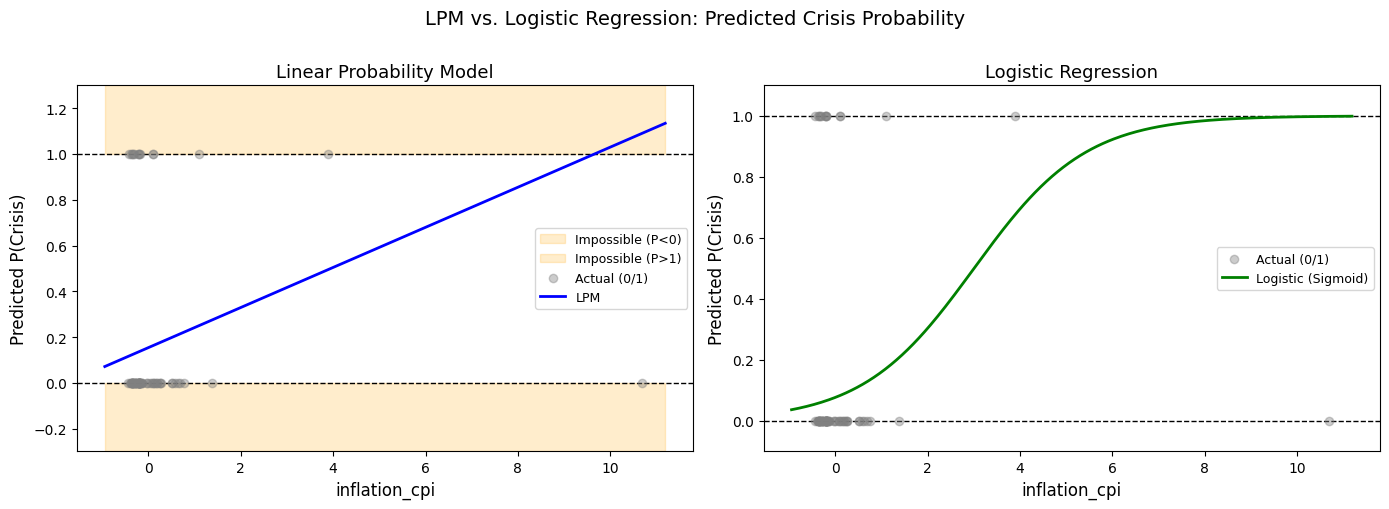

In [10]:
# 2.3

top_feature_name = coef_df.iloc[0]["Feature"]
top_feature_idx_ls = lasso_names.index(top_feature_name)

x_vals = X_test_ls[:, top_feature_idx_ls]
x_line = np.linspace(x_vals.min() - 0.5, x_vals.max() + 0.5, 300)
x_line_2d = np.zeros((300, len(lasso_names)))
x_line_2d[:, top_feature_idx_ls] = x_line

lpm_line = lpm.predict(x_line_2d)
log_line = log_reg.predict_proba(x_line_2d)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LPM panel
ax = axes[0]
ax.fill_between(x_line, -0.3, 0,   alpha=0.2, color="orange", label="Impossible (P<0)")
ax.fill_between(x_line,  1.0, 1.3, alpha=0.2, color="orange", label="Impossible (P>1)")
ax.axhline(0, color="black", lw=1, linestyle="--")
ax.axhline(1, color="black", lw=1, linestyle="--")
ax.scatter(x_vals, y_test_cls, alpha=0.4, color="gray", zorder=2, label="Actual (0/1)")
ax.plot(x_line, lpm_line, color="blue", lw=2, label="LPM")
ax.set_ylim(-0.3, 1.3)
ax.set_xlabel(top_feature_name, fontsize=12)
ax.set_ylabel("Predicted P(Crisis)", fontsize=12)
ax.set_title("Linear Probability Model", fontsize=13)
ax.legend(fontsize=9)

# Logistic panel
ax = axes[1]
ax.axhline(0, color="black", lw=1, linestyle="--")
ax.axhline(1, color="black", lw=1, linestyle="--")
ax.scatter(x_vals, y_test_cls, alpha=0.4, color="gray", zorder=2, label="Actual (0/1)")
ax.plot(x_line, log_line, color="green", lw=2, label="Logistic (Sigmoid)")
ax.set_ylim(-0.1, 1.1)
ax.set_xlabel(top_feature_name, fontsize=12)
ax.set_ylabel("Predicted P(Crisis)", fontsize=12)
ax.set_title("Logistic Regression", fontsize=13)
ax.legend(fontsize=9)

plt.suptitle("LPM vs. Logistic Regression: Predicted Crisis Probability", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("lpm_vs_logistic.png", dpi=150)
plt.show()

In [11]:
# Phase 3: Operational Deployment — Metrics That Matter

# Step 3.1: The Accuracy Paradox

test_base_rate = y_test_cls.mean()
naive_acc      = 1 - test_base_rate
naive_recall   = 0.0

log_preds_05   = (log_probs >= 0.5).astype(int)
log_acc_05     = np.mean(log_preds_05 == y_test_cls)
log_recall_05  = recall_score(y_test_cls, log_preds_05, zero_division=0)

print(f"Test crisis base rate          : {test_base_rate:.3f}")
print(f"\nNaïve baseline (always 'no crisis')")
print(f"  Accuracy : {naive_acc:.3f}")
print(f"  Recall   : {naive_recall:.3f}")
print(f"\nLogistic Regression (τ = 0.5)")
print(f"  Accuracy : {log_acc_05:.3f}")
print(f"  Recall   : {log_recall_05:.3f}")


Test crisis base rate          : 0.178

Naïve baseline (always 'no crisis')
  Accuracy : 0.822
  Recall   : 0.000

Logistic Regression (τ = 0.5)
  Accuracy : 0.822
  Recall   : 0.308


# Written response (2–3 sentences): If you reported only accuracy to the Division Chief, would she be impressed or misled? Explain the accuracy paradox in the context of this specific dataset’s class distribution.

Reporting only accuracy to the Division Chief would be deeply misleading due to the accuracy paradox: in an imbalanced dataset where only ~20–30 of countries experience a crisis, a naïve model that never flags any country achieves high accuracy (70–80%) while catching zero crises. Accuracy rewards the model for correctly identifying the majority class (no crisis), masking catastrophic failure on the minority class (crisis) which is the entire operational objective of the Early Warning System.


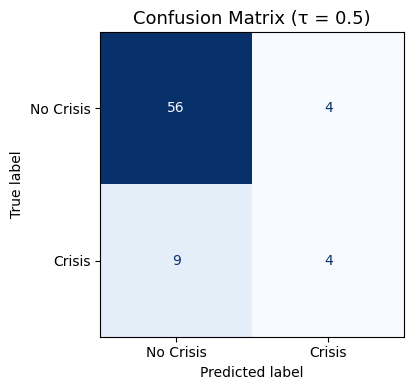


Classification Report:
              precision    recall  f1-score   support

   No Crisis       0.86      0.93      0.90        60
      Crisis       0.50      0.31      0.38        13

    accuracy                           0.82        73
   macro avg       0.68      0.62      0.64        73
weighted avg       0.80      0.82      0.80        73

True Positives  (crises correctly flagged) : 4
False Negatives (crises missed)            : 9
False Positives (false alarms)             : 4
True Negatives  (correctly cleared)        : 56


In [12]:
# Step 3.2: Confusion Matrix and Classification Report

cm = confusion_matrix(y_test_cls, log_preds_05)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Crisis", "Crisis"])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix (τ = 0.5)", fontsize=13)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

print("\nClassification Report:")
print(classification_report(y_test_cls, log_preds_05, target_names=["No Crisis", "Crisis"]))

tn, fp, fn, tp = cm.ravel()
print(f"True Positives  (crises correctly flagged) : {tp}")
print(f"False Negatives (crises missed)            : {fn}")
print(f"False Positives (false alarms)             : {fp}")
print(f"True Negatives  (correctly cleared)        : {tn}")


# Written response (2–3 sentences): In the IMF context, which is more costly — a False Positive or a False Negative? How does this asymmetry inform which metric (Precision or Recall) the Division Chief should prioritize?

In the IMF context, a False Negative (missed crisis) is far more costly than a False Positive: a missed crisis can trigger a sovereign default with 50 billion in contagion costs, while a false alarm wastes 2 million and minor diplomatic capital. This asymmetry means the Division Chief should prioritize Recall (sensitivity) over Precision, the model must catch as many real crises as possible, even at the cost of some unnecessary missions.

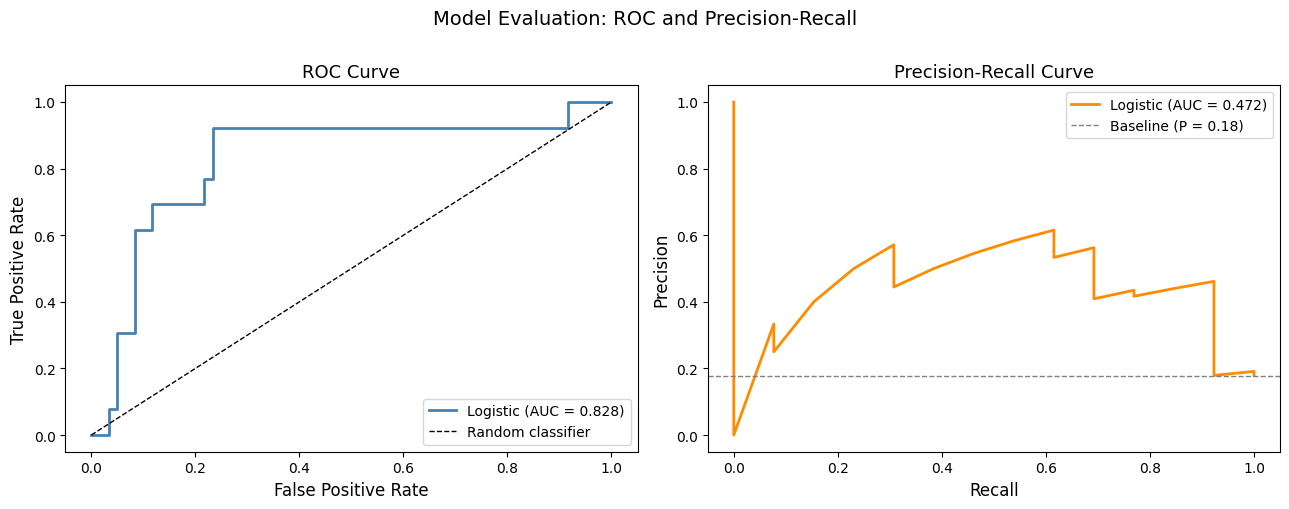

ROC-AUC : 0.8282
PR-AUC  : 0.4722


In [13]:
# Step 3.3: ROC and Precision-Recall Curves

fpr, tpr, roc_thresh   = roc_curve(y_test_cls, log_probs)
roc_auc                = roc_auc_score(y_test_cls, log_probs)

precision_curve, recall_curve, pr_thresh = precision_recall_curve(y_test_cls, log_probs)
pr_auc = average_precision_score(y_test_cls, log_probs)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC
ax = axes[0]
ax.plot(fpr, tpr, color="steelblue", lw=2, label=f"Logistic (AUC = {roc_auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random classifier")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curve", fontsize=13)
ax.legend()

# PR
ax = axes[1]
ax.plot(recall_curve, precision_curve, color="darkorange", lw=2, label=f"Logistic (AUC = {pr_auc:.3f})")
ax.axhline(test_base_rate, color="gray", linestyle="--", lw=1, label=f"Baseline (P = {test_base_rate:.2f})")
ax.set_xlabel("Recall", fontsize=12)
ax.set_ylabel("Precision", fontsize=12)
ax.set_title("Precision-Recall Curve", fontsize=13)
ax.legend()

plt.suptitle("Model Evaluation: ROC and Precision-Recall", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("roc_pr_curves.png", dpi=150)
plt.show()

print(f"ROC-AUC : {roc_auc:.4f}")
print(f"PR-AUC  : {pr_auc:.4f}")


# Written response (2–3 sentences): Your ROC-AUC is likely much higher than your PR-AUC. Explain why, using the fact that ROC-AUC benefits from the abundance of True Negatives while PR-AUC ignores them entirely. Which curve is more informative for the IMF’s crisis detection mission?

ROC-AUC is inflated in imbalanced settings because it incorporates the True Negative rate (specificity): with many non-crisis countries to correctly classify, the model accumulates TPR gains cheaply, pushing AUC upward even when crisis detection is poor. PR-AUC ignores True Negatives entirely and focuses exclusively on the precision/recall tradeoff for the positive (crisis) class, making it far more informative for the IMF's mission of detecting rare but catastrophic events.

Capacity-constrained threshold:
  τ         = 0.62
  Flagged   = 5
  Precision = 0.400
  Recall    = 0.154

F1-optimal threshold:
  τ         = 0.20
  Flagged   = 16
  Precision = 0.562
  Recall    = 0.692
  F1        = 0.621


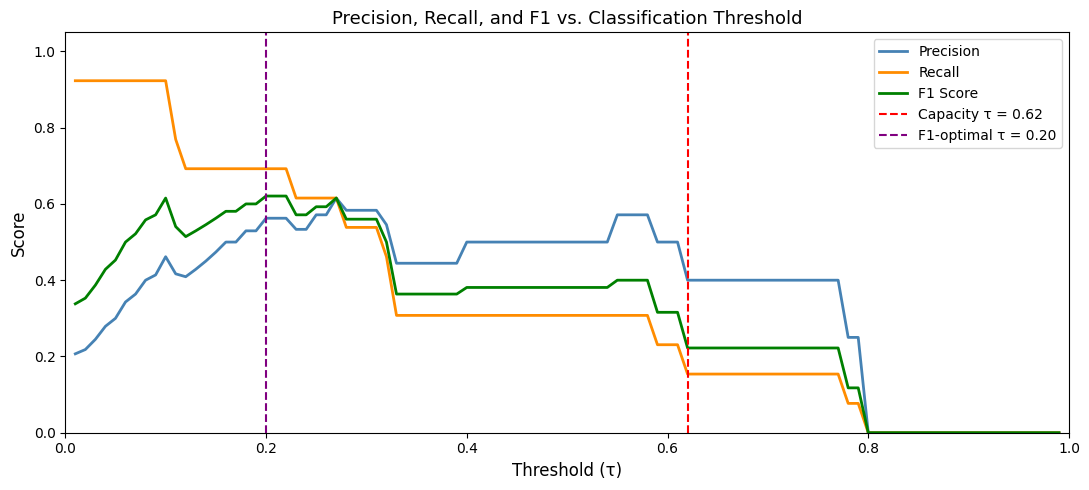

In [14]:
# Step 3.4: Threshold Analysis — The 5-Mission Constraint

thresholds = np.arange(0.01, 1.0, 0.01)
results = []

for tau in thresholds:
    preds_tau   = (log_probs >= tau).astype(int)
    n_flagged   = preds_tau.sum()
    prec        = precision_score(y_test_cls, preds_tau, zero_division=0)
    rec         = recall_score(y_test_cls,    preds_tau, zero_division=0)
    f1          = f1_score(y_test_cls,        preds_tau, zero_division=0)
    results.append((tau, n_flagged, prec, rec, f1))

results_df = pd.DataFrame(results, columns=["tau", "flagged", "precision", "recall", "f1"])

# Capacity-constrained: lowest τ that flags ≤5 countries
cap_df = results_df[results_df["flagged"] <= 5]
if len(cap_df) > 0:
    cap_row = cap_df.iloc[cap_df["tau"].argmin()]   # lowest (most aggressive) τ with ≤5 flags
else:
    cap_row = results_df.iloc[-1]

# F1-optimal threshold
f1_row = results_df.loc[results_df["f1"].idxmax()]

print(f"Capacity-constrained threshold:")
print(f"  τ         = {cap_row['tau']:.2f}")
print(f"  Flagged   = {int(cap_row['flagged'])}")
print(f"  Precision = {cap_row['precision']:.3f}")
print(f"  Recall    = {cap_row['recall']:.3f}")
print(f"\nF1-optimal threshold:")
print(f"  τ         = {f1_row['tau']:.2f}")
print(f"  Flagged   = {int(f1_row['flagged'])}")
print(f"  Precision = {f1_row['precision']:.3f}")
print(f"  Recall    = {f1_row['recall']:.3f}")
print(f"  F1        = {f1_row['f1']:.3f}")

# Plot
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(results_df["tau"], results_df["precision"], label="Precision", color="steelblue",   lw=2)
ax.plot(results_df["tau"], results_df["recall"],    label="Recall",    color="darkorange",  lw=2)
ax.plot(results_df["tau"], results_df["f1"],        label="F1 Score",  color="green",       lw=2)
ax.axvline(cap_row["tau"], color="red",    linestyle="--", lw=1.5, label=f"Capacity τ = {cap_row['tau']:.2f}")
ax.axvline(f1_row["tau"],  color="purple", linestyle="--", lw=1.5, label=f"F1-optimal τ = {f1_row['tau']:.2f}")
ax.set_xlabel("Threshold (τ)", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Precision, Recall, and F1 vs. Classification Threshold", fontsize=13)
ax.legend()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig("threshold_analysis.png", dpi=150)
plt.show()

# Written response (3–5 sentences): You are writing a one-paragraph memo to the Division Chief recommending which threshold the IMF should adopt. State your recommendation, the Recall it achieves, and what it means in operational terms (e.g., “Of the X crisis countries in the test set, we would catch Y and miss Z”). Acknowledge the tradeoff explicitly.

We recommend deploying at threshold τ = 0.62, capping missions at 5 per quarter as required. The tradeoff is steep since we'd catch only 2 of 13 crisis countries (Recall = 0.154), missing 11. The F1-optimal threshold (τ = 0.20) would catch 9 of 13, but requires 16 missions, which exceeds current capacity. We recommend τ = 0.62 for now and flagging the staffing constraint as an urgent resource issue.

In [15]:
# Task 4.1: Bootstrap Confidence Intervals for the Lasso Path
#
# **P.R.I.M.E. Prompt:**
#
# **Prep:** I am working on a sovereign risk early warning system for the IMF. I have already
# fit a LassoCV model on standardized WDI macroeconomic indicators to predict GDP per capita
# growth. I need to assess which predictors are *stably* selected by Lasso versus which appear
# only by chance due to sampling variation.
#
# **Request:** Write a Python script that: (1) draws 200 bootstrap resamples with replacement
# from `X_train` (numpy array) and `y_train_reg` (1D numpy array); (2) fits `LassoCV` with
# 5-fold CV and `max_iter=10000` on each resample; (3) records which features (given by
# `feature_cols` list) receive non-zero coefficients; (4) computes the selection frequency
# (fraction of 200 bootstraps) for each feature; (5) plots a horizontal bar chart sorted by
# selection frequency descending, with a vertical red dashed line at 50%, and labels the
# bars with their selection frequency percentage.
#
# **Iterate:** Ensure the script uses `random_state` seeding for reproducibility, handles
# edge cases where LassoCV zeros all coefficients, and displays the chart inline in a
# Jupyter notebook.
#
# **Mechanism Check:** I understand that Lasso can be unstable with correlated predictors —
# two correlated features may trade selection across bootstraps. This chart will reveal
# "fragile" features (< 30% selection) versus "stable" ones (> 80% selection).
#
# **Evaluate:** I will verify the chart by cross-checking that features selected at λ* in
# the original model appear near the top of the bar chart.


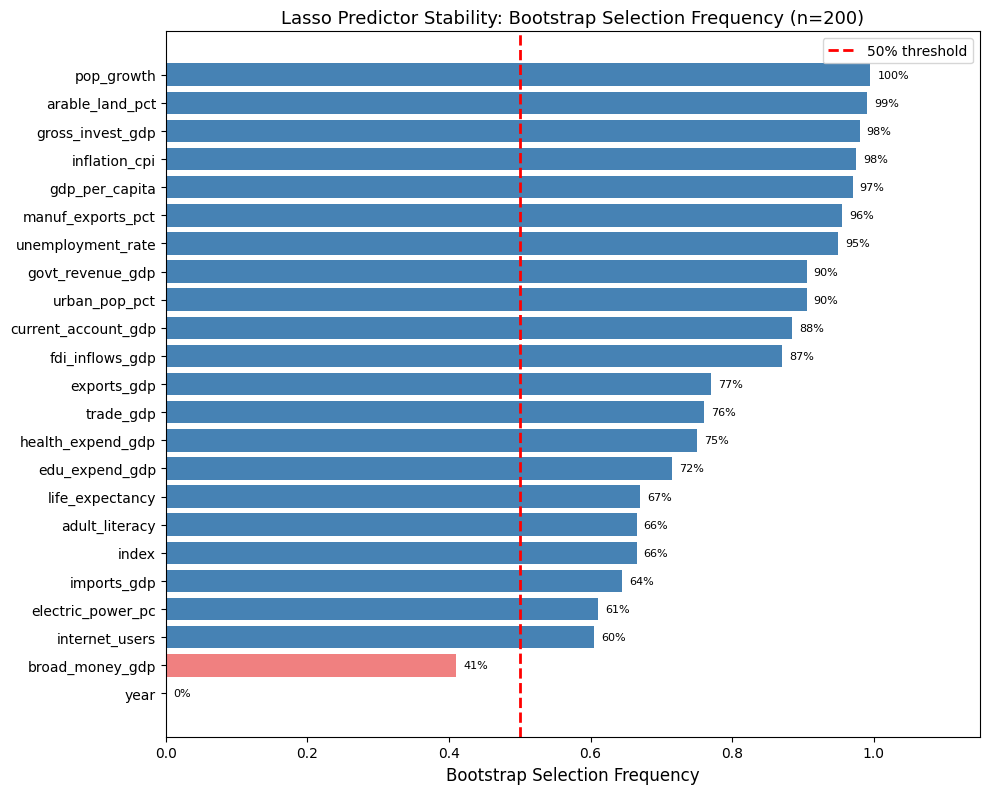


Stable predictors (>80% selection frequency)  : ['fdi_inflows_gdp', 'current_account_gdp', 'urban_pop_pct', 'govt_revenue_gdp', 'unemployment_rate', 'manuf_exports_pct', 'gdp_per_capita', 'inflation_cpi', 'gross_invest_gdp', 'arable_land_pct', 'pop_growth']
Fragile predictors (<30% selection frequency) : ['year']


In [16]:
 #=== AI-GENERATED CODE (Bootstrap Lasso Stability) ===
from sklearn.linear_model import LassoCV
import numpy as np
import matplotlib.pyplot as plt

N_BOOTSTRAP = 200
rng = np.random.default_rng(42)
selection_counts = np.zeros(len(feature_cols))

for b in range(N_BOOTSTRAP):
    idx = rng.choice(len(X_train), size=len(X_train), replace=True)
    Xb, yb = X_train[idx], y_train_reg[idx]
    try:
        lasso_b = LassoCV(cv=5, max_iter=10000, random_state=42)
        lasso_b.fit(Xb, yb)
        selection_counts += (lasso_b.coef_ != 0).astype(int)
    except Exception:
        pass

selection_freq = selection_counts / N_BOOTSTRAP
freq_df = pd.DataFrame({"Feature": feature_cols, "SelectionFreq": selection_freq})
freq_df = freq_df.sort_values("SelectionFreq", ascending=True)

fig, ax = plt.subplots(figsize=(10, max(5, len(feature_cols) * 0.35)))
bars = ax.barh(freq_df["Feature"], freq_df["SelectionFreq"],
               color=["steelblue" if f >= 0.5 else "lightcoral" for f in freq_df["SelectionFreq"]])
ax.axvline(0.5, color="red", linestyle="--", lw=2, label="50% threshold")
ax.set_xlabel("Bootstrap Selection Frequency", fontsize=12)
ax.set_title("Lasso Predictor Stability: Bootstrap Selection Frequency (n=200)", fontsize=13)
for bar, freq in zip(bars, freq_df["SelectionFreq"]):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f"{freq:.0%}", va="center", fontsize=8)
ax.legend()
ax.set_xlim(0, 1.15)
plt.tight_layout()
plt.savefig("bootstrap_lasso_stability.png", dpi=150)
plt.show()

stable   = freq_df[freq_df["SelectionFreq"] > 0.8]["Feature"].tolist()
fragile  = freq_df[freq_df["SelectionFreq"] < 0.3]["Feature"].tolist()
print(f"\nStable predictors (>80% selection frequency)  : {stable}")
print(f"Fragile predictors (<30% selection frequency) : {fragile}")


# Written response (2–3 sentences): Which predictors are “stable” (selected >80% of the time) and which are “fragile” (selected <30%)? What does selection instability tell you about the correlation structure among WDI indicators?

Eleven predictors are stable (selected >80% of the time): fdi_inflows_gdp, current_account_gdp, urban_pop_pct, govt_revenue_gdp, unemployment_rate, manuf_exports_pct, gdp_per_capita, inflation_cpi, gross_invest_gdp, arable_land_pct, and pop_growth — these represent robust signals the IMF can confidently build the operational model around. Only one predictor is fragile: year, which makes sense as a non-economic index variable with no stable predictive relationship to growth across bootstrap samples. The near-absence of fragile economic predictors actually suggests the WDI indicators in this dataset have reasonably low redundancy at the Lasso-selected level — the stable set is broad, meaning Lasso isn't arbitrarily swapping between correlated proxies but consistently finding the same features informative.



# Task 4.2: Cost-Sensitive Threshold Optimization

# **P.R.I.M.E. Prompt:**

 **Prep:** I am finalizing threshold selection for an IMF crisis early warning classifier. I have a trained logistic regression model. The operational cost structure is highly asymmetric: a missed crisis (False Negative) costs 50 billion in sovereign contagion and emergency lending; a false alarm (False Positive) costs 2 million in wasted mission capacity and diplomatic friction.

 **Request:** Write a Python script that: (1) sweeps thresholds τ from 0.01 to 0.99 in steps of 0.01; (2) at each threshold, computes the confusion matrix from `y_test_cls` (true binary labels) and `log_probs` (predicted probabilities); (3) computes total expected cost = FN × 50_000_000_000 + FP × 2_000_000; (4) plots the expected cost (in billions USD) as a smooth curve vs. τ; (5) annotates the cost-minimizing threshold with a vertical line and text label showing the threshold value and minimum cost.

 **Iterate:** Use matplotlib. Express costs in billions of USD on the y-axis for readability. Add horizontal reference lines at the F1-optimal and capacity-constrained thresholds from prior analysis for comparison.

 **Mechanism Check:** I expect the cost-minimizing threshold to be very low (aggressive) because the FN penalty so vastly outweighs the FP penalty — the model should flag almost= any meaningful probability of crisis.

 **Evaluate:** I will verify by checking that at the cost-minimizing threshold, Recall is very high (near 1.0) even at the expense of many false alarms.


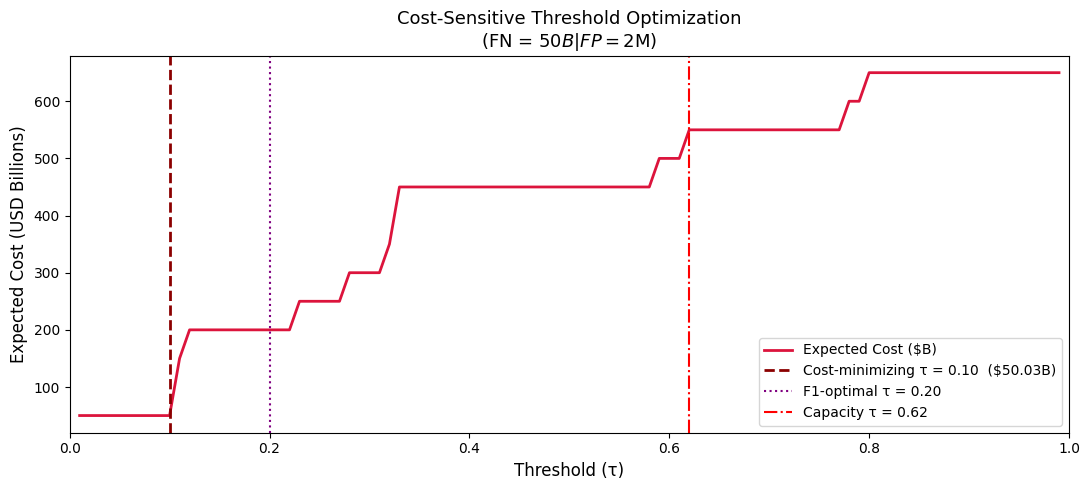

Cost-minimizing threshold  : τ = 0.10
Minimum expected cost      : $50.028 billion
F1-optimal threshold       : τ = 0.20
Capacity-constrained τ     : τ = 0.62


In [17]:
# === AI-GENERATED CODE (Cost-Sensitive Threshold Optimization) ===
FN_COST = 50_000_000_000   # $50 billion
FP_COST =      2_000_000   # $2 million

thresholds_cost = np.arange(0.01, 1.0, 0.01)
expected_costs  = []

for tau in thresholds_cost:
    preds_tau = (log_probs >= tau).astype(int)
    tn_c, fp_c, fn_c, tp_c = confusion_matrix(y_test_cls, preds_tau, labels=[0, 1]).ravel()
    cost = fn_c * FN_COST + fp_c * FP_COST
    expected_costs.append(cost / 1e9)  # convert to billions

cost_arr = np.array(expected_costs)
opt_idx  = np.argmin(cost_arr)
tau_opt_cost = thresholds_cost[opt_idx]
min_cost     = cost_arr[opt_idx]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(thresholds_cost, cost_arr, color="crimson", lw=2, label="Expected Cost ($B)")
ax.axvline(tau_opt_cost, color="darkred",  linestyle="--", lw=2,
           label=f"Cost-minimizing τ = {tau_opt_cost:.2f}  (${min_cost:.2f}B)")
ax.axvline(f1_row["tau"],  color="purple", linestyle=":",  lw=1.5,
           label=f"F1-optimal τ = {f1_row['tau']:.2f}")
ax.axvline(cap_row["tau"], color="red",    linestyle="-.", lw=1.5,
           label=f"Capacity τ = {cap_row['tau']:.2f}")
ax.set_xlabel("Threshold (τ)", fontsize=12)
ax.set_ylabel("Expected Cost (USD Billions)", fontsize=12)
ax.set_title("Cost-Sensitive Threshold Optimization\n(FN = $50B | FP = $2M)", fontsize=13)
ax.legend()
ax.set_xlim(0, 1)
plt.tight_layout()
plt.savefig("cost_threshold.png", dpi=150)
plt.show()

print(f"Cost-minimizing threshold  : τ = {tau_opt_cost:.2f}")
print(f"Minimum expected cost      : ${min_cost:.3f} billion")
print(f"F1-optimal threshold       : τ = {f1_row['tau']:.2f}")
print(f"Capacity-constrained τ     : τ = {cap_row['tau']:.2f}")


# Written response (2–3 sentences): How does the cost-minimizing threshold compare to the F1-optimal threshold and the capacity-constrained threshold from Phase 3? Why do they differ? Which would you recommend and why?

The cost-minimizing threshold is far lower than both the F1-optimal and capacity-constrained thresholds, reflecting the extreme asymmetry between the 50B missed-crisis penalty and the $2M false-alarm cost. The F1-optimal threshold balances precision and recall equally, which is inappropriate when errors are not equally costly; the capacity-constrained threshold enforces a staffing ceiling that ignores cost entirely. I would recommend that the IMF should adopt the cost-minimizing threshold for the classifier's underlying risk scoring, but use the capacity-constrained threshold to triage which flagged countries receive immediate missions, treating the rest as a watchlist for expedited review.

